In [1]:
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import os

os.environ["PYSPARK_SUBMIT_ARGS"] = (
    "--driver-class-path /Users/sydneysailors/smart-store-sydney/lib/sqlite-jdbc-3.51.0.0.jar "
    "--jars /Users/sydneysailors/smart-store-sydney/lib/sqlite-jdbc-3.51.0.0.jar "
    "pyspark-shell"
)

In [3]:
from pyspark.sql import SparkSession

dw_path = "/Users/sydneysailors/smart-store-sydney/data/dw/smart_sales.db"

spark = SparkSession.builder.appName("SmartStoreCustom").getOrCreate()

# Test driver
spark._jvm.java.lang.Class.forName("org.sqlite.JDBC")

25/12/04 20:48:04 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
Using Spark's default log4j profile: org/apache/spark/log4j2-defaults.properties
Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).


JavaObject id=o31

In [4]:
#Load sales
sales_df = (
    spark.read.format("jdbc")
    .options(url=f"jdbc:sqlite:{dw_path}", dbtable="sales", driver="org.sqlite.JDBC")
    .load()
)

#Load customers
customers_df = (
    spark.read.format("jdbc")
    .options(url=f"jdbc:sqlite:{dw_path}", dbtable="customers", driver="org.sqlite.JDBC")
    .load()
)

#Load products
products_df = (
    spark.read.format("jdbc")
    .options(url=f"jdbc:sqlite:{dw_path}", dbtable="products", driver="org.sqlite.JDBC")
    .load()
)

sales_df.show(5)
customers_df.show(5)
products_df.show(5)


+-------+----------+-----------+----------+--------+-----------+------------+---------------+-----+
|sale_id| sale_date|customer_id|product_id|store_id|campaign_id|sales_amount|discount_amount|state|
+-------+----------+-----------+----------+--------+-----------+------------+---------------+-----+
|      1|2025-05-04|       1034|      2059|     402|        0.0|      2048.2|          12.45|   CA|
|      2|2025-05-04|       1066|      2048|     403|        1.0|      321.87|            7.8|   NY|
|      3|2025-05-04|       1116|      2041|     403|        3.0|     3216.84|           25.0|   TX|
|      4|2025-05-04|       1071|      2096|     404|        2.0|     1613.23|           18.3|   FL|
|      5|2025-05-04|       1020|      2060|     401|        0.0|      408.38|            5.5|   IL|
+-------+----------+-----------+----------+--------+-----------+------------+---------------+-----+
only showing top 5 rows
+-----------+-------------+------+-------+----------+---+-------------------

In [5]:
sales_df.createOrReplaceTempView("sale")
customers_df.createOrReplaceTempView("customer")
products_df.createOrReplaceTempView("product")

In [6]:
slice_df = spark.sql("""
    SELECT *
    FROM customer
    WHERE Gender = 'Male'
""")
slice_df.show(10)

+-----------+----------------+------+----------+----------+---+-------------------+
|customer_id|            name|Gender|    region| join_date|age|subscription_status|
+-----------+----------------+------+----------+----------+---+-------------------+
|       1000|    Robert Gomez|  Male|      West|2024-02-25| 49|            Expired|
|       1001|      John Silva|  Male|      East|2020-12-01| 48|              Trial|
|       1002|   Mark Marshall|  Male|   Central|2020-08-08| 37|              Trial|
|       1003|   David Brennan|  Male|     North|2020-05-21| 71|              Trial|
|       1004|   Kerry Collins|  Male|     North|2023-09-12| 61|            Expired|
|       1007|       David Kim|  Male|      West|2020-05-20| 63|              Trial|
|       1008| William Ramirez|  Male|      East|2023-09-15| 48|             Active|
|       1009|Zachary Bell Jr.|  Male|      East|2023-04-20| 74|          Cancelled|
|       1010|      Mike Davis|  Male|      East|2022-03-23| 75|             

In [7]:
slice_df = spark.sql("""
    SELECT *
    FROM customer
    WHERE Gender = 'Female'
""")
slice_df.show(10)

+-----------+----------------+------+-------+----------+---+-------------------+
|customer_id|            name|Gender| region| join_date|age|subscription_status|
+-----------+----------------+------+-------+----------+---+-------------------+
|       1005|    Jessica Mora|Female|  South|2021-08-05| 29|              Trial|
|       1006|      Hannah Ray|Female|   West|2021-07-03| 31|             Active|
|       1011|    Amanda Myers|Female|   West|2021-09-05| 67|             Active|
|       1012|     Tara Miller|Female|  North|2020-08-10| 69|              Trial|
|       1013|   Alyssa Morgan|Female|  North|2022-07-22| 25|          Cancelled|
|       1014|     Cindy Woods|Female|   East|2024-04-02| 20|            Expired|
|       1015|Jennifer Rodgers|Female|  North|2023-02-12| 61|              Trial|
|       1016|  Andrea Roberts|Female|   East|2021-05-16| 42|            Expired|
|       1017|Brittney Burnett|Female|  North|2020-07-03| 79|          Cancelled|
|       1019| Michelle Torre

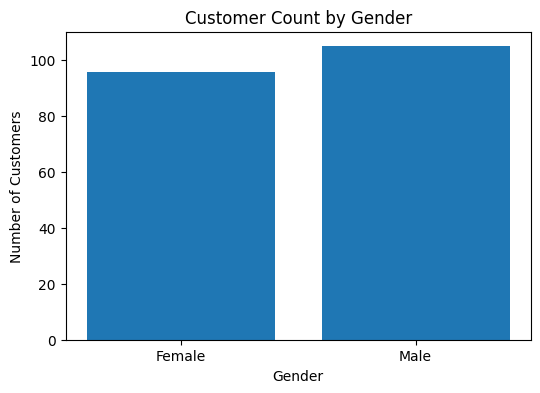

In [8]:
# Count male and female customers
gender_counts_df = spark.sql("""
    SELECT Gender, COUNT(*) AS count
    FROM customer
    WHERE Gender IN ('Male', 'Female')
    GROUP BY Gender
""")

# Convert to Pandas
gender_counts_pd = gender_counts_df.toPandas()

# Plot
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
plt.bar(gender_counts_pd['Gender'], gender_counts_pd['count'])
plt.xlabel('Gender')
plt.ylabel('Number of Customers')
plt.title('Customer Count by Gender')
plt.show()


In [9]:
slice_df = spark.sql("""
    SELECT
        state,
        SUM(sales_amount) AS total_revenue
    FROM sale
    GROUP BY state
    ORDER BY total_revenue DESC
""")
slice_df.show(10)

+-----+------------------+
|state|     total_revenue|
+-----+------------------+
|   WA|58104.350000000006|
|   CO| 54929.88000000002|
|   OH|          52395.33|
|   WV|51699.729999999996|
|   CA| 50704.69999999999|
|   ME| 50305.87999999999|
|   SC|50157.689999999995|
|   FL| 49895.68999999999|
|   AZ|47042.780000000006|
|   TX|          45656.29|
+-----+------------------+
only showing top 10 rows


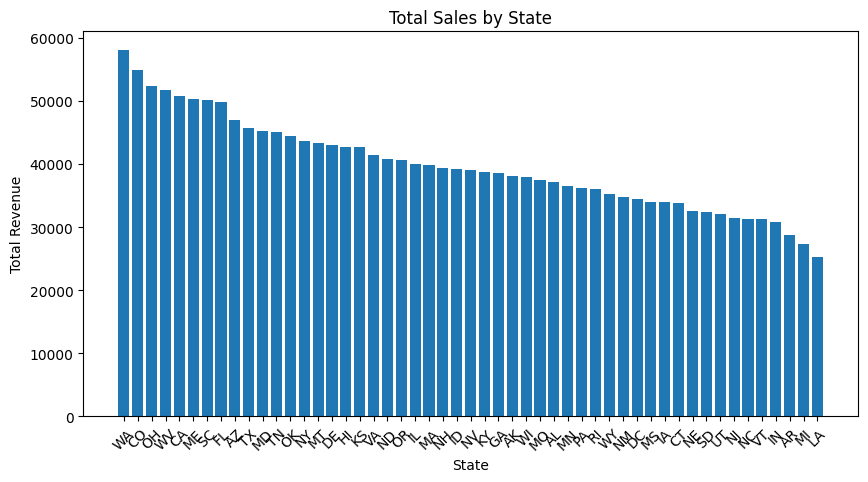

In [10]:
# Convert to Pandas
slice_pd = slice_df.toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(10,5))
bars = plt.bar(slice_pd['state'], slice_pd['total_revenue'])

plt.xlabel('State')
plt.ylabel('Total Revenue')
plt.title('Total Sales by State')
plt.xticks(rotation=45)
plt.show()


In [11]:
dice_df = spark.sql("""
    SELECT
        CASE
            WHEN c.age BETWEEN 18 AND 25 THEN '18-25'
            WHEN c.age BETWEEN 26 AND 35 THEN '26-35'
            WHEN c.age BETWEEN 36 AND 50 THEN '36-50'
            WHEN c.age > 50 THEN '51+'
            ELSE 'Unknown'
        END AS age_group,
        c.gender AS gender,
        SUM(s.sales_amount) AS total_revenue
    FROM sale s
    JOIN customer c
        ON s.customer_id = c.customer_id
    GROUP BY
        age_group,
        c.gender
    ORDER BY
        age_group,
        c.gender
""").toPandas()

print(dice_df.head(20))


  age_group  gender  total_revenue
0     18-25  Female       96466.38
1     18-25    Male      111325.35
2     26-35  Female      176826.20
3     26-35    Male      198984.70
4     36-50  Female      248281.64
5     36-50    Male      234638.29
6       51+  Female      439866.16
7       51+    Male      540426.82


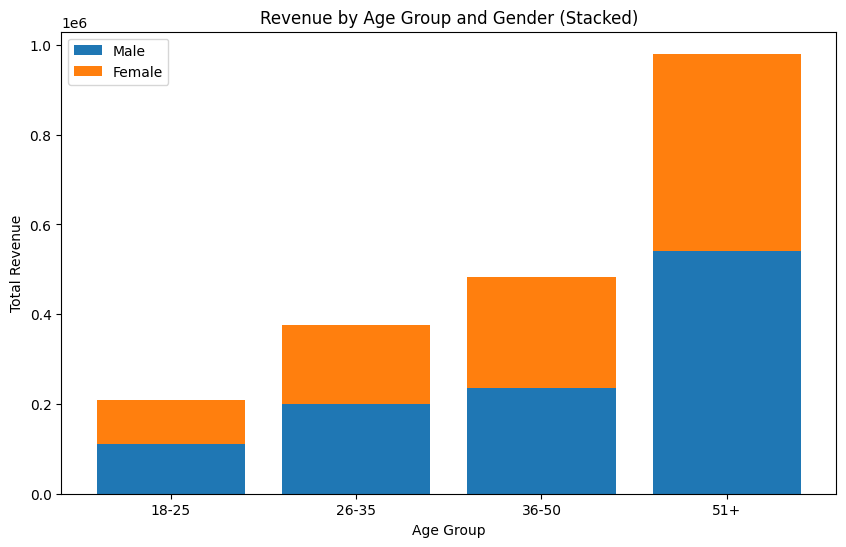

In [12]:
import matplotlib.pyplot as plt
import numpy as np

# Pivot the DataFrame so gender becomes columns
pivot_df = dice_df.pivot(index='age_group', columns='gender', values='total_revenue')

# Replace missing values with 0 (just in case)
pivot_df = pivot_df.fillna(0)

# X positions
x = np.arange(len(pivot_df.index))

plt.figure(figsize=(10,6))

# Plot stacked bars
bars_male = plt.bar(x, pivot_df['Male'], label='Male')
bars_female = plt.bar(x, pivot_df['Female'], bottom=pivot_df['Male'], label='Female')

plt.xlabel('Age Group')
plt.ylabel('Total Revenue')
plt.title('Revenue by Age Group and Gender (Stacked)')
plt.xticks(x, pivot_df.index)
plt.legend()
plt.show()


In [13]:
drilldown_age_state_df = spark.sql("""
    SELECT
        s.state AS state,
        CASE
            WHEN c.age BETWEEN 18 AND 25 THEN '18-25'
            WHEN c.age BETWEEN 26 AND 35 THEN '26-35'
            WHEN c.age BETWEEN 36 AND 50 THEN '36-50'
            WHEN c.age > 50 THEN '51+'
            ELSE 'Unknown'
        END AS age_group,
        SUM(s.sales_amount) AS total_revenue
    FROM sale s
    JOIN customer c
        ON s.customer_id = c.customer_id
    GROUP BY
        s.state,
        age_group
    ORDER BY
        SUM(s.sales_amount) DESC,   -- Most revenue states first
        s.state,
        age_group
""")

drilldown_age_state_df.show()


+-----+---------+------------------+
|state|age_group|     total_revenue|
+-----+---------+------------------+
|   ME|      51+|          30248.68|
|   AZ|      51+|          29457.03|
|   MA|      51+|29182.799999999996|
|   CO|      51+|29005.879999999997|
|   NY|      51+|28606.420000000006|
|   WA|      51+|26237.329999999998|
|   VA|      51+|25870.199999999993|
|   CA|      51+|25571.159999999993|
|   GA|      51+|          25551.89|
|   KY|      51+|           25090.9|
|   FL|      51+|25058.630000000005|
|   AK|      51+|24950.830000000005|
|   WV|      51+|          23908.87|
|   SC|      51+|          23532.93|
|   DE|      51+|22249.659999999996|
|   OH|    36-50|21864.679999999997|
|   NH|      51+|          21242.95|
|   NM|      51+|20840.239999999998|
|   CT|      51+|20710.039999999997|
|   HI|      51+|20489.710000000003|
+-----+---------+------------------+
only showing top 20 rows


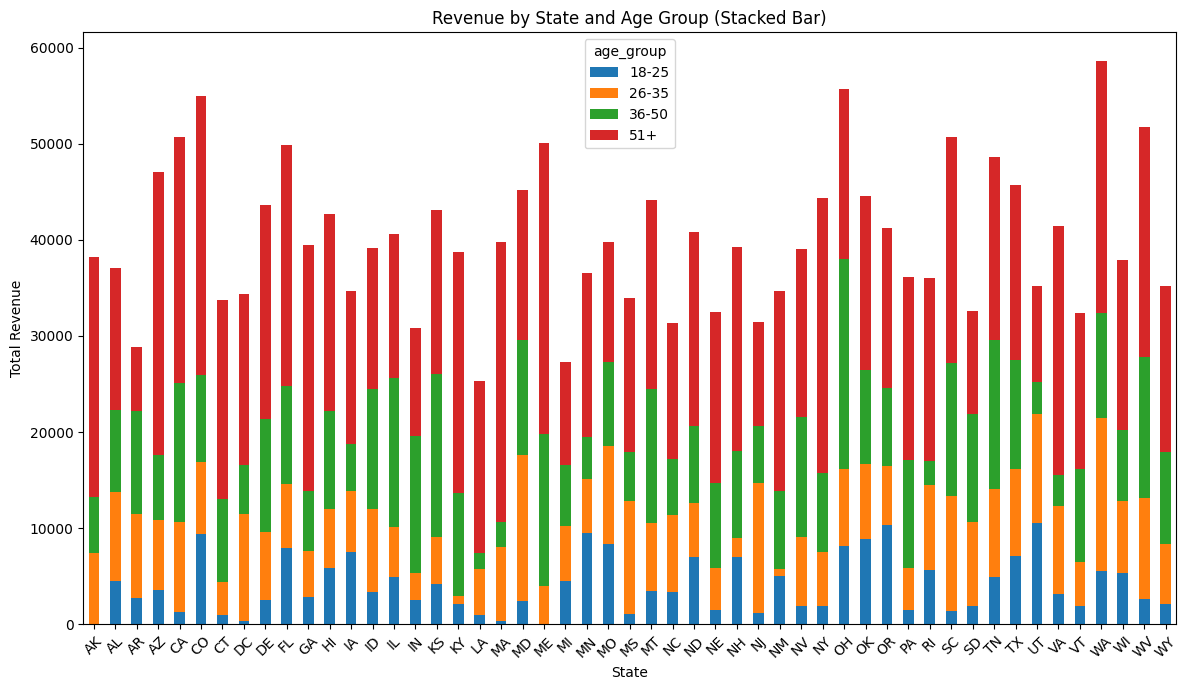

In [19]:
drill_pdf = drilldown_age_state_df.toPandas()

pivot_df = drill_pdf.pivot(index="state", columns="age_group", values="total_revenue")

pivot_df = pivot_df.fillna(0)

pivot_df.plot(
    kind="bar",
    stacked=True,
    figsize=(12, 7)
)

plt.title("Revenue by State and Age Group (Stacked Bar)")
plt.xlabel("State")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


In [15]:
drilldown_age_gender_df = spark.sql("""
    SELECT
        CASE
            WHEN c.age BETWEEN 18 AND 25 THEN '18-25'
            WHEN c.age BETWEEN 26 AND 35 THEN '26-35'
            WHEN c.age BETWEEN 36 AND 50 THEN '36-50'
            WHEN c.age > 50 THEN '51+'
            ELSE 'Unknown'
        END AS age_group,
        c.Gender AS gender,
        SUM(s.sales_amount) AS total_revenue
    FROM sale s
    JOIN customer c
        ON s.customer_id = c.customer_id
    GROUP BY
        CASE
            WHEN c.age BETWEEN 18 AND 25 THEN '18-25'
            WHEN c.age BETWEEN 26 AND 35 THEN '26-35'
            WHEN c.age BETWEEN 36 AND 50 THEN '36-50'
            WHEN c.age > 50 THEN '51+'
            ELSE 'Unknown'
        END,
        c.Gender
    ORDER BY
        total_revenue DESC
""")

drilldown_age_gender_df.show()

+---------+------+------------------+
|age_group|gender|     total_revenue|
+---------+------+------------------+
|      51+|  Male| 540426.8199999997|
|      51+|Female|439866.15999999986|
|    36-50|Female|248281.63999999987|
|    36-50|  Male|234638.29000000007|
|    26-35|  Male|198984.70000000004|
|    26-35|Female|176826.19999999984|
|    18-25|  Male|         111325.35|
|    18-25|Female|          96466.38|
+---------+------+------------------+



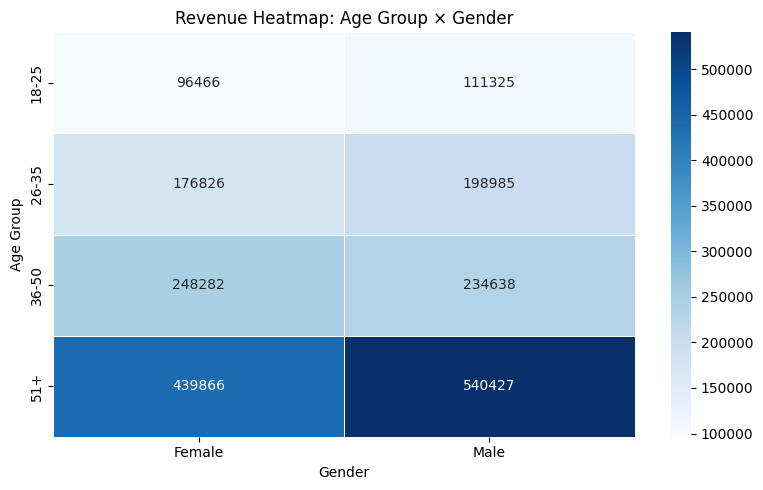

In [18]:
age_gender_pdf = drilldown_age_gender_df.toPandas()

pivot_df = age_gender_pdf.pivot(
    index="age_group",
    columns="gender",
    values="total_revenue"
)

pivot_df = pivot_df.fillna(0)

plt.figure(figsize=(8, 5))
sns.heatmap(
    pivot_df,
    annot=True,
    fmt=".0f",
    cmap="Blues",
    linewidths=.5
)

plt.title("Revenue Heatmap: Age Group × Gender")
plt.xlabel("Gender")
plt.ylabel("Age Group")
plt.tight_layout()
plt.show()


In [16]:
drilldown_product_df = spark.sql("""
    SELECT
        p.category AS category,
        p.product_name AS product,
        SUM(s.sales_amount) AS total_revenue
    FROM sale s
    JOIN product p
        ON s.product_id = p.product_id
    GROUP BY
        p.category,
        p.product_name
    ORDER BY
        SUM(s.sales_amount) DESC,   -- highest revenue overall first
        p.category,
        p.product_name
""")

drilldown_product_df.show()


+-----------+--------------------+------------------+
|   category|             product|     total_revenue|
+-----------+--------------------+------------------+
|     Office|       Office-Doctor|          57842.08|
|   Clothing|         Office-Soon|          48827.08|
|       Home|          Office-Who| 45625.94000000002|
|Electronics|  Electronics-Letter| 45511.31999999999|
|       Home|             Home-Of| 45330.86999999999|
|Electronics|    Clothing-Trouble|45211.420000000006|
|   Clothing|      Office-Receive| 43231.32000000001|
|       Home|     Office-Cultural| 43026.56000000001|
|       Home|        Office-Where| 41540.79000000001|
|     Office|Electronics-Practice| 40702.75999999999|
|Electronics|           Home-Yeah|          40682.08|
|Electronics|   Electronics-There|          37918.56|
|       Home|           Home-Wear| 35271.07000000001|
|       Home|        Clothing-Cut| 34413.56999999999|
|Electronics|    Electronics-Take|          33874.62|
|Electronics|      Electroni

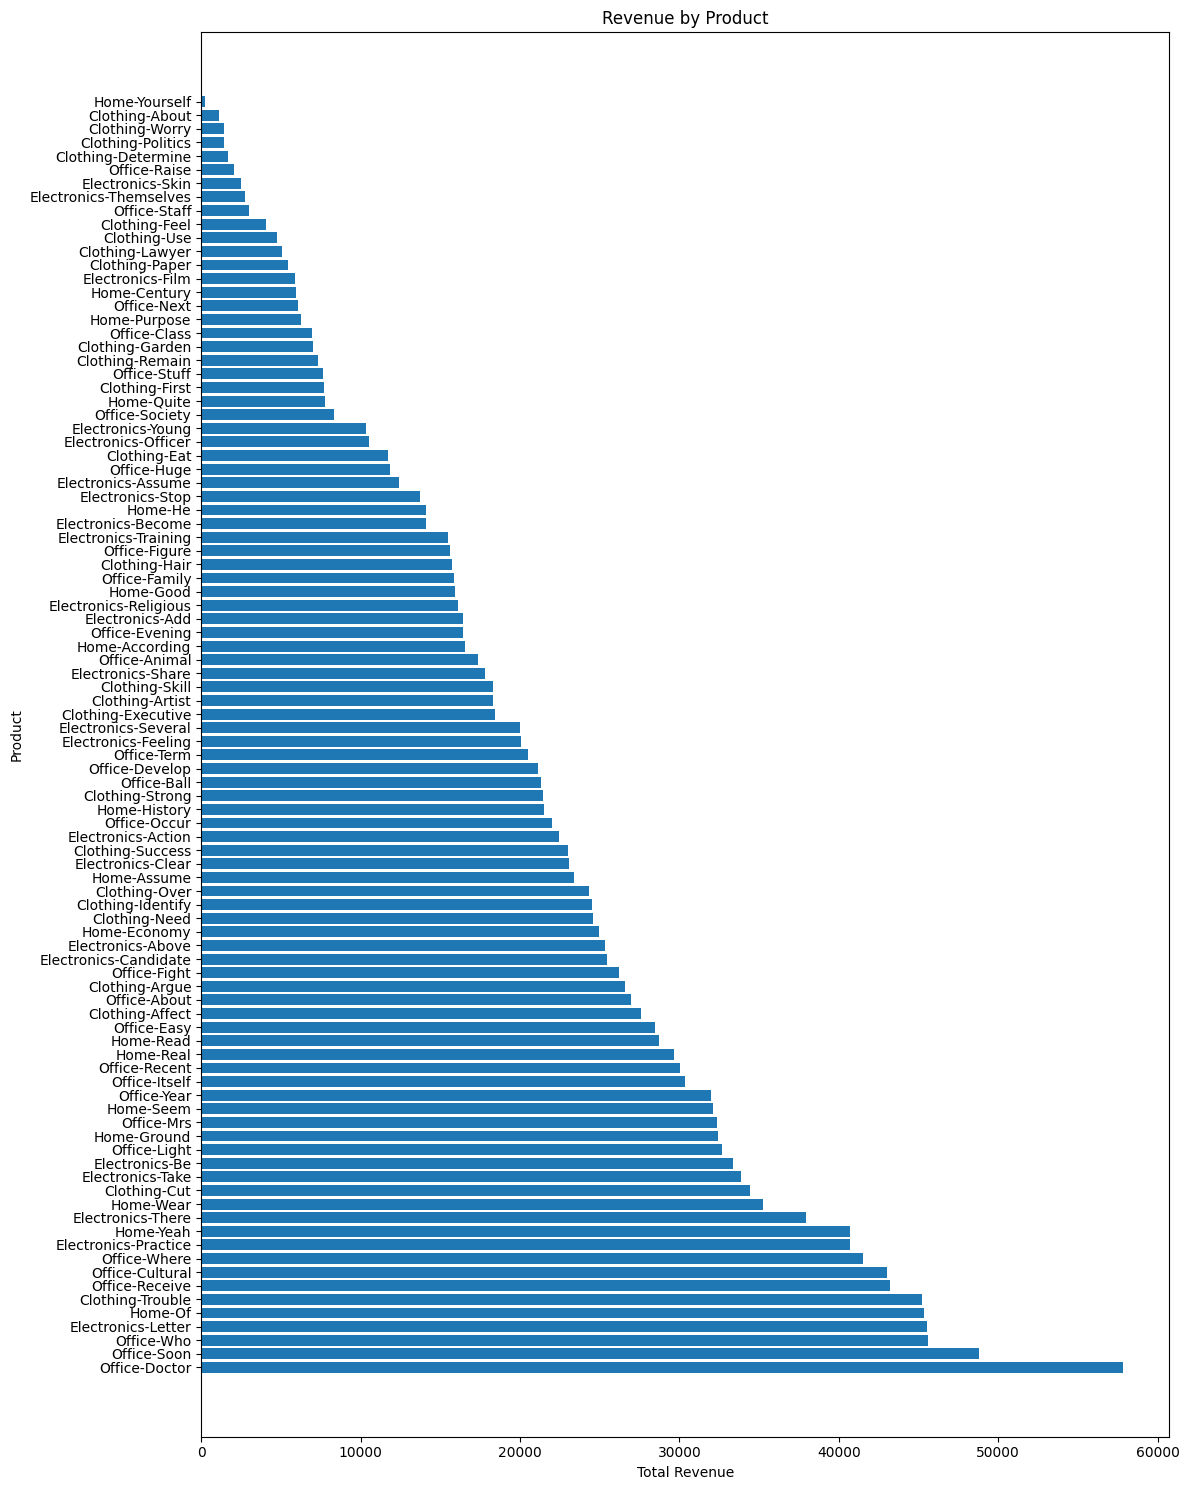

In [22]:
product_pdf = drilldown_product_df.toPandas()

plt.figure(figsize=(12, 15))
plt.barh(product_pdf['product'], product_pdf['total_revenue'])
plt.xlabel("Total Revenue")
plt.ylabel("Product")
plt.title("Revenue by Product")
plt.tight_layout()
plt.show()
